##### Comical cat and dogs classifier
While boring at this point, we will be building a basic cats and dogs classifier, this is order to ensure we are actually following the book properly, so we can be sure we actually learn the concepts that the books aim to convey. 

In [1]:
# import all vision tools from fastai2
from fastai.vision.all import *

In [ ]:
from fastprogress.fastprogress import NBMasterBar

# monkey-patch NBMasterBar.show to handle missing 'out' attribute
original_show = NBMasterBar.show

# create monkey patch function
def patched_show(self):
    if not hasattr(self, 'out'):
        # create a dummy output if missing (for VS Code notebooks)
        from IPython.display import display, HTML
        try:
            self.out = display(HTML(''), display_id=True)
        except:
            # if display fails, create a minimal output object
            class DummyOut:
                def update(self, x): pass
            self.out = DummyOut()
    return original_show(self)

# set monkey patch
NBMasterBar.show = patched_show


In [3]:
path = untar_data(URLs.PETS) / 'images'

In [4]:
path

Path('/Users/kosisochukwuasuzu/.fastai/data/oxford-iiit-pet/images')

In [5]:
from typing import List

In [6]:
def is_cat(x: List[str]): return x[0].isupper()

In [7]:
dls = ImageDataLoaders.from_name_func(path, get_image_files(path), 
                                      valid_pct=0.2, seed=42, 
                                      label_func=is_cat, 
                                      item_tfms=Resize(224))

In [8]:
learn = vision_learner(dls, resnet34, metrics=error_rate)

In [9]:
from IPython.display import clear_output, display, HTML

In [10]:
out = display(HTML("<p> hello world </p>"), display_id=True)

In [11]:
# now fine_tune should work
learn.fine_tune(8)

epoch,train_loss,valid_loss,error_rate,time


epoch,train_loss,valid_loss,error_rate,time
0,0.168885,0.020594,0.008796,01:02


epoch,train_loss,valid_loss,error_rate,time


epoch,train_loss,valid_loss,error_rate,time
0,0.047278,0.015666,0.008119,01:29
1,0.048776,0.039275,0.012855,01:26
2,0.037126,0.084884,0.020974,01:26
3,0.028097,0.013914,0.004736,01:26
4,0.014112,0.018201,0.006089,01:27
5,0.010736,0.009440,0.001353,01:25
6,0.004110,0.011525,0.002706,01:26
7,0.002557,0.011286,0.002706,01:26


In [13]:
!pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [14]:
import ipywidgets as widgets

In [17]:
uploader = widgets.FileUpload()
uploader

FileUpload(value=(), description='Upload')

In [28]:
img = PILImage.create("/Users/kosisochukwuasuzu/Developer/ai-experiments-v2/opensource-ai-notebooks/Multiethnic Students Typing.jpg")

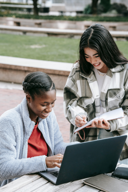

In [29]:
img.to_thumb(192)

In [30]:
isa_cat, _, probs = learn.predict(img)
print(f"is this a cat? {isa_cat}")
print(f"probability it is a cat {probs[1].item():.2f}")

is this a cat? True
probability it is a cat 0.82
